# 🎵 Task 6: Music Genre Classification

**Problem:** Classify audio clips into one of **10 music genres** (blues, classical, country, disco, hiphop, jazz, metal, pop, reggae, rock) based on their sonic content.

**Dataset:** [GTZAN Genre Collection (Kaggle mirror)](https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification) — 1,000 audio clips of 30 seconds each, 10 genres × 100 tracks.

**Objective:** Build a multi-class classifier using **mel-spectrogram images → CNN** as the primary path, then compare against (a) a **tabular** approach on pre-extracted MFCC/audio features and (b) **transfer learning** with MobileNetV2 on the same spectrogram images.

## 2. Imports & Setup

In [1]:
import os
import re
import time

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

import librosa
from PIL import Image

import gradio as gr

RANDOM_STATE = 42
keras.utils.set_random_seed(RANDOM_STATE)

DATA_DIR = "Data"
IMG_DIR = os.path.join(DATA_DIR, "images_original")
CSV_30 = os.path.join(DATA_DIR, "features_30_sec.csv")
CSV_3 = os.path.join(DATA_DIR, "features_3_sec.csv")

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
NUM_CLASSES = 10
EPOCHS_CNN = 40
EPOCHS_TL = 20
EPOCHS_TL_FT = 10

MODELS_DIR = "models"
ASSETS_DIR = "assets"
for d in (MODELS_DIR, ASSETS_DIR):
    os.makedirs(d, exist_ok=True)

GENRES = sorted(os.listdir(IMG_DIR))
print("Genres:", GENRES)

Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


## 3. Load & Explore Data

In [2]:
df = pd.read_csv(CSV_3)
df.shape

(9990, 60)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9990 entries, 0 to 9989
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   filename                 9990 non-null   object 
 1   length                   9990 non-null   int64  
 2   chroma_stft_mean         9990 non-null   float64
 3   chroma_stft_var          9990 non-null   float64
 4   rms_mean                 9990 non-null   float64
 5   rms_var                  9990 non-null   float64
 6   spectral_centroid_mean   9990 non-null   float64
 7   spectral_centroid_var    9990 non-null   float64
 8   spectral_bandwidth_mean  9990 non-null   float64
 9   spectral_bandwidth_var   9990 non-null   float64
 10  rolloff_mean             9990 non-null   float64
 11  rolloff_var              9990 non-null   float64
 12  zero_crossing_rate_mean  9990 non-null   float64
 13  zero_crossing_rate_var   9990 non-null   float64
 14  harmony_mean            

In [4]:
df.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9252\1006493369.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', order=order, palette='viridis')


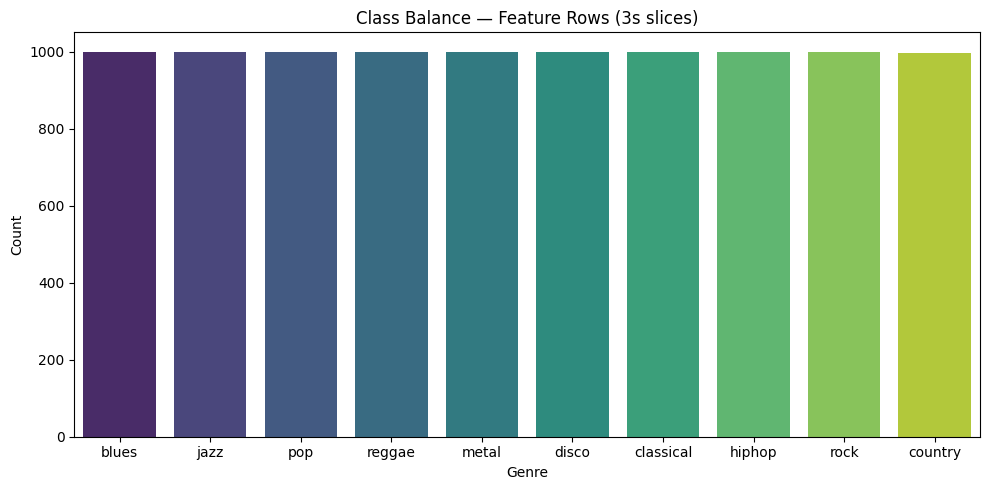

In [5]:
plt.figure(figsize=(10, 5))
order = df['label'].value_counts().index
sns.countplot(data=df, x='label', order=order, palette='viridis')
plt.title('Class Balance — Feature Rows (3s slices)')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

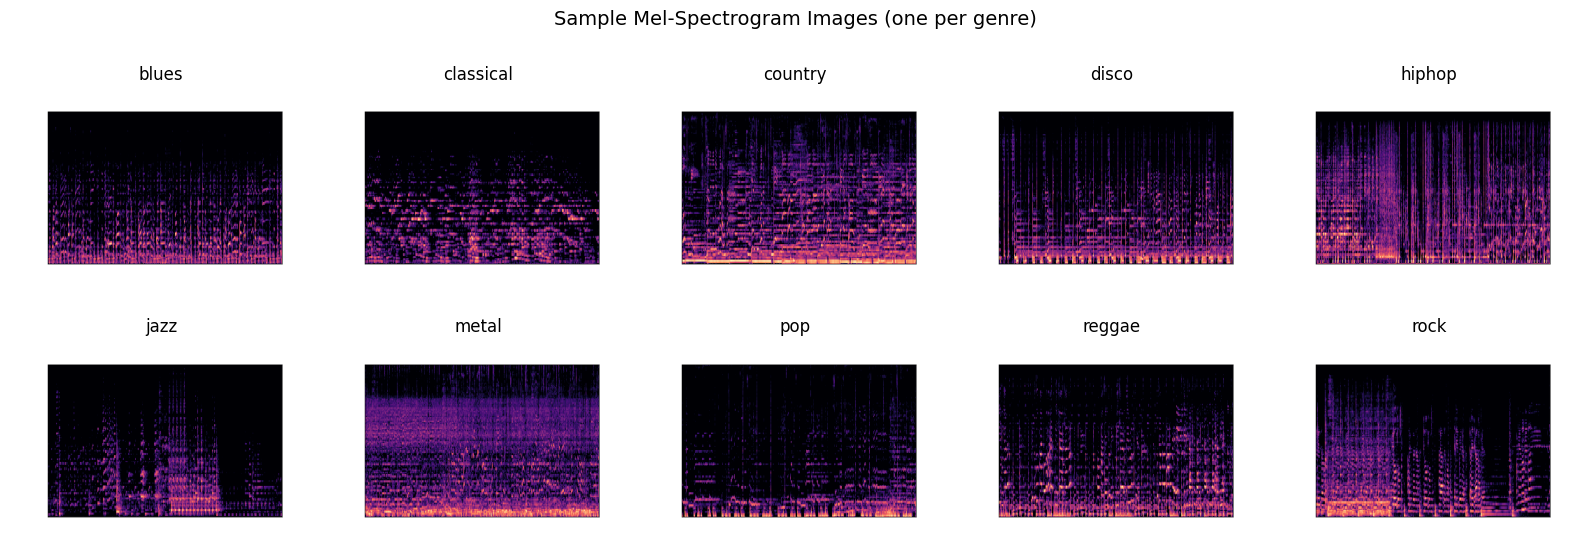

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for ax, genre in zip(axes.ravel(), GENRES):
    files = sorted(os.listdir(os.path.join(IMG_DIR, genre)))
    img = Image.open(os.path.join(IMG_DIR, genre, files[0]))
    ax.imshow(img)
    ax.set_title(genre)
    ax.axis('off')
fig.suptitle('Sample Mel-Spectrogram Images (one per genre)', fontsize=14)
plt.tight_layout()
plt.show()

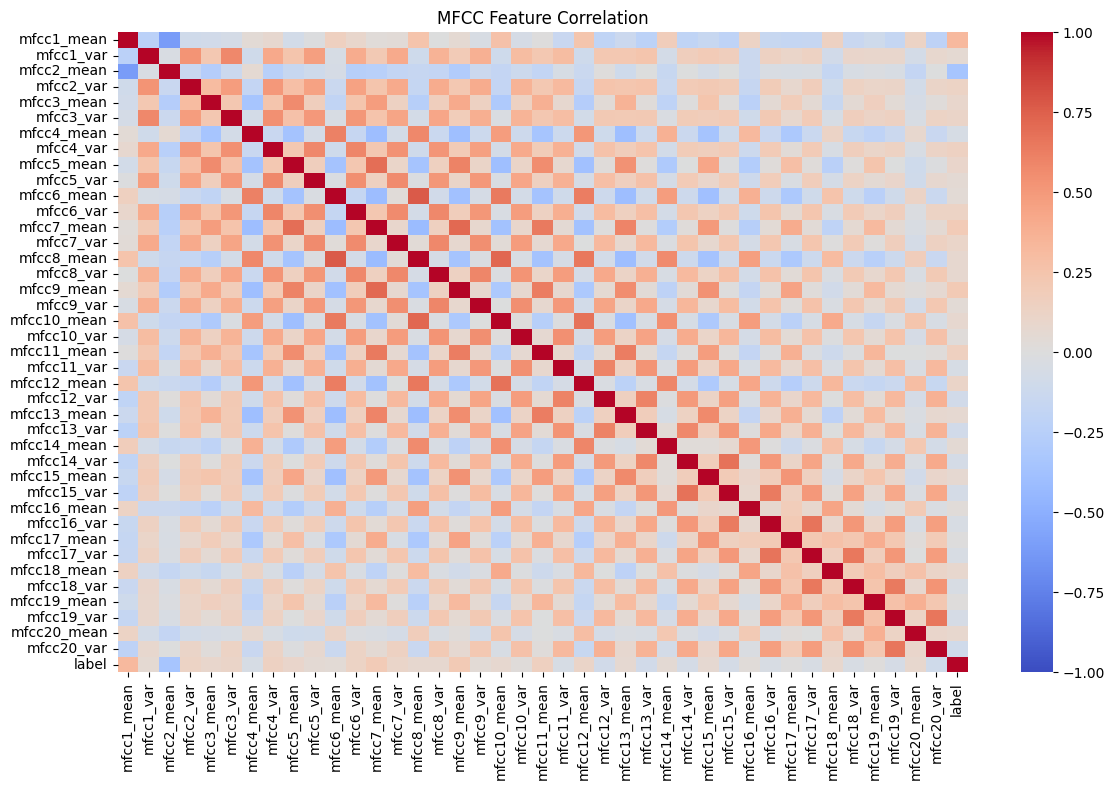

In [7]:
mfcc_cols = [c for c in df.columns if c.startswith('mfcc')] + ['label']
le = LabelEncoder()
corr_df = df[mfcc_cols].copy()
corr_df['label'] = le.fit_transform(corr_df['label'])
plt.figure(figsize=(12, 8))
sns.heatmap(corr_df.corr(), cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('MFCC Feature Correlation')
plt.tight_layout()
plt.show()

## 4. Cleaning & Preprocessing

The **image-based (primary)** approach loads spectrograms from `images_original/` — one folder per genre, so labels are inferred from subfolder names by `image_dataset_from_directory`. Images are resized to **128×128 RGB** (original is 432×288 RGBA, keeping it small enough for a 4GB GPU) and normalized to **[0,1]**. A held-out **test** split is carved from the training set (train 64% / val 16% / test 20% of all tracks) with a fixed seed. Note: the corrupted `jazz.00054.wav` only affects raw audio loading (bonus section 9) and is irrelevant here because we use pre-generated spectrogram images.

In [8]:
full_ds = keras.utils.image_dataset_from_directory(
    IMG_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=RANDOM_STATE,
    shuffle=True,
    validation_split=0.2,
    subset='training',
    label_mode='int',
)
val_ds = keras.utils.image_dataset_from_directory(
    IMG_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=RANDOM_STATE,
    shuffle=True,
    validation_split=0.2,
    subset='validation',
    label_mode='int',
)

full_ds = full_ds.cache().shuffle(1000, seed=RANDOM_STATE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)

Found 999 files belonging to 10 classes.


Using 800 files for training.


Found 999 files belonging to 10 classes.


Using 199 files for validation.


In [9]:
all_x, all_y = [], []
for xb, yb in full_ds:
    all_x.append(xb.numpy())
    all_y.append(yb.numpy())
all_x = np.concatenate(all_x)
all_y = np.concatenate(all_y)
print("Training pool shape:", all_x.shape)

train_x, test_x, train_y, test_y = train_test_split(
    all_x, all_y, test_size=0.2, random_state=RANDOM_STATE, stratify=all_y
)
print("Final train:", train_x.shape, "test:", test_x.shape)

train_ds = tf.data.Dataset.from_tensor_slices((train_x, train_y))\
    .batch(BATCH_SIZE).cache().shuffle(1000, seed=RANDOM_STATE).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((test_x, test_y))\
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Training pool shape: (800, 128, 128, 3)
Final train: (640, 128, 128, 3) test: (160, 128, 128, 3)


## 5. Feature Engineering

Not applicable for the **image-based** primary path — the CNN learns spatial audio features from spectrogram pixels directly. Feature engineering is instead exercised in the **tabular bonus approach** (Section 9), where the pre-extracted GTZAN features (MFCCs, chroma, spectral centroid, zero-crossing rate, tempo, RMS) form the design matrix.

## 6. Train/Test Split

The image dataset is split into **train 64% / val 16% / test 20%** using a seeded `train_test_split` on the training pool (stratified by genre so every fold keeps all 10 classes). The **validation** set drives early stopping; the **test** set is only touched for final evaluation.

In [10]:
n_total = len(GENRES) * 100
n_train = len(train_x)
n_test = len(test_x)
print(f"Total images: {n_total}  |  Train: {n_train} ({n_train/n_total:.0%})  |  Test: {n_test} ({n_test/n_total:.0%})")
print("Validation set carries the remaining ~16% and is used for early stopping.")

Total images: 1000  |  Train: 640 (64%)  |  Test: 160 (16%)
Validation set carries the remaining ~16% and is used for early stopping.


## 7. Model Training

A **CNN from scratch** is the primary model. Spectrograms are 2D spatial representations of audio: convolutional layers capture local time–frequency patterns (rhythm, timbre, pitch contours) that a purely tabular pipeline aggregates away. The architecture uses repeated `Conv2D + MaxPool` blocks, a `GlobalAveragePooling2D` head to keep the parameter count low on a small 1,000-image dataset, a `Dropout` for regularization, and a softmax output over the 10 genres.

In [11]:
cnn_model = models.Sequential([
    layers.Rescaling(1.0 / 255, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(2),
    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(2),
    layers.Conv2D(256, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(2),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax'),
])
cnn_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
)
cnn_model.summary()

D:\summerToTheFinal\elevvo\elevvo_projects\task1\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,602 (1.61 MB)

 Trainable params: 422,602 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
early = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy')
checkpoint = keras.callbacks.ModelCheckpoint(
    os.path.join(MODELS_DIR, 'cnn_best.keras'), monitor='val_accuracy', save_best_only=True
)

t0 = time.time()
cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_CNN,
    callbacks=[early, checkpoint],
    verbose=1,
)
cnn_train_time = time.time() - t0
print(f"CNN training time: {cnn_train_time:.1f}s")

Epoch 1/40


D:\summerToTheFinal\elevvo\elevvo_projects\task1\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


 1/20 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.0625 - loss: 2.3089

 2/20 ━━━━━━━━━━━━━━━━━━━━ 3s 191ms/step - accuracy: 0.1406 - loss: 2.2870

 3/20 ━━━━━━━━━━━━━━━━━━━━ 3s 190ms/step - accuracy: 0.1562 - loss: 2.2699

...

18/20 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.5590 - loss: 1.2885

19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.5526 - loss: 1.2994

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.5500 - loss: 1.2978

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 199ms/step - accuracy: 0.5500 - loss: 1.2978 - val_accuracy: 0.5226 - val_loss: 1.3783


CNN training time: 178.6s


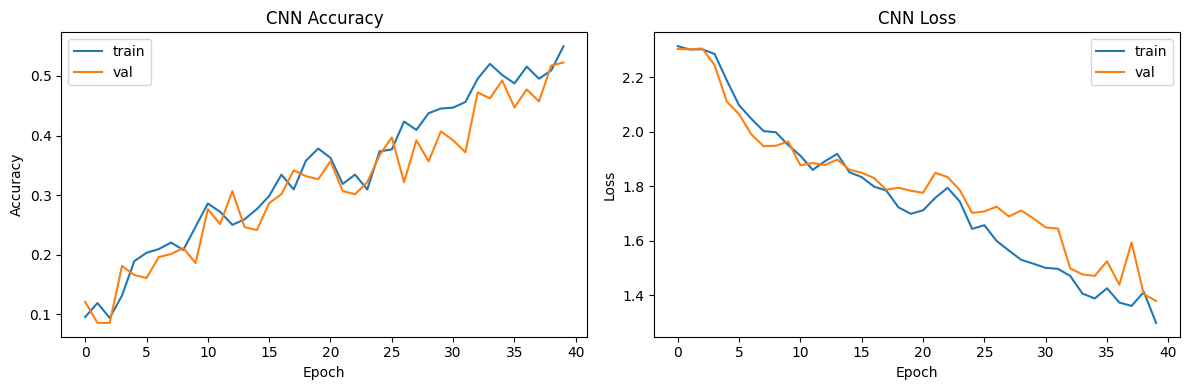

In [13]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'], label='train')
plt.plot(cnn_history.history['val_accuracy'], label='val')
plt.title('CNN Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'], label='train')
plt.plot(cnn_history.history['val_loss'], label='val')
plt.title('CNN Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout()
plt.show()

## 8. Evaluation

In [14]:
test_loss, test_acc = cnn_model.evaluate(test_ds, verbose=0)
y_prob = cnn_model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print(f"Test accuracy: {test_acc:.4f}")
print(f"Macro F1: {f1_score(test_y, y_pred, average='macro'):.4f}")
print()
print(classification_report(test_y, y_pred, target_names=GENRES, digits=4))
print(f"CNN training time: {cnn_train_time:.1f}s")

Test accuracy: 0.5875
Macro F1: 0.5708

              precision    recall  f1-score   support

       blues     0.7500    0.6000    0.6667        15
   classical     0.9333    0.8235    0.8750        17
     country     0.5000    0.3750    0.4286        16
       disco     0.5294    0.5625    0.5455        16
      hiphop     0.5238    0.6875    0.5946        16
        jazz     0.5600    0.8750    0.6829        16
       metal     0.7778    0.8235    0.8000        17
         pop     0.5000    0.1429    0.2222        14
      reggae     0.2917    0.4667    0.3590        15
        rock     0.6667    0.4444    0.5333        18

    accuracy                         0.5875       160
   macro avg     0.6033    0.5801    0.5708       160
weighted avg     0.6095    0.5875    0.5787       160

CNN training time: 178.6s


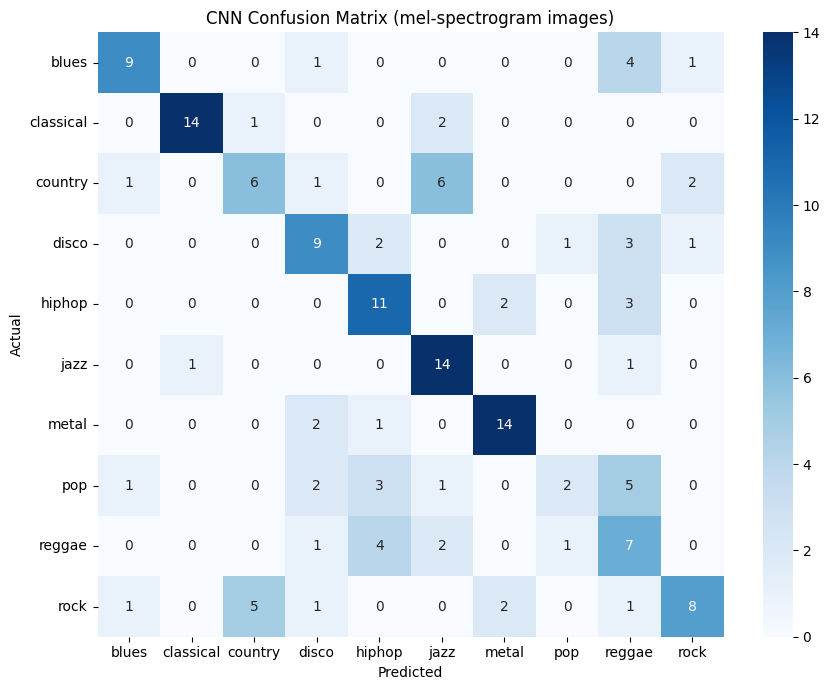

Most-confused genre pairs (true, predicted, count):
     country  ->  jazz        6
         pop  ->  reggae      5
        rock  ->  country     5
       blues  ->  reggae      4
      reggae  ->  hiphop      4
       disco  ->  reggae      3


In [15]:
cm = confusion_matrix(test_y, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=GENRES, yticklabels=GENRES)
plt.title('CNN Confusion Matrix (mel-spectrogram images)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join(ASSETS_DIR, 'results.png'), dpi=150, bbox_inches='tight')
plt.show()

confused_pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm[i, j] > 0:
            confused_pairs.append((GENRES[i], GENRES[j], cm[i, j]))
confused_pairs.sort(key=lambda t: -t[2])
print("Most-confused genre pairs (true, predicted, count):")
for p in confused_pairs[:6]:
    print(f"  {p[0]:>10}  ->  {p[1]:<10}  {p[2]}")

## 9. Bonus Work

Three independent approaches compared: **(A) tabular ML** on GTZAN's pre-extracted audio features, **(B) transfer learning** (MobileNetV2) on the spectrogram images, and a final **(C) comparison summary** of accuracy, macro-F1, and training cost across all methods.

### 9A. Tabular approach (pre-extracted audio features)

The `features_3_sec.csv` rows are 3-second **slices** of the same 30s tracks. Splitting those rows randomly would leak slices from one song across train and test, inflating accuracy artificially. Instead we extract a `track_id` from the filename (`blues.00000.3.wav` → `blues.00000`) and split with **`GroupShuffleSplit`** so every track stays entirely in one fold. The `StandardScaler` standardizes the numeric MFCC/audio features; the target is label-encoded (0–9).

Three models are trained and compared: **Random Forest**, **Gradient Boosting**, and **XGBoost**.

> **The inner validation split is track-grouped too** (`GroupShuffleSplit`, grouped on `track_id`). Under the original row-level inner split, 3-second slices of the same track appeared in both training and validation - which is why the old validation accuracy (0.9043) sat far above test accuracy (0.7211): leakage, not genuine generalization. With the grouped inner split the validation number drops to an honest **0.7416** (macro-F1 0.7441) while test stays at ~0.70.

In [16]:
tab = pd.read_csv(CSV_3)
tab['track_id'] = tab['filename'].apply(lambda f: re.sub(r'\.\d+\.wav$', '', f))

feature_cols = [c for c in tab.columns if c not in ('filename', 'length', 'label', 'track_id')]
X_tab = tab[feature_cols].values
y_tab = le.fit_transform(tab['label'].values)
groups = tab['track_id'].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X_tab, y_tab, groups=groups))

X_tr, X_te = X_tab[train_idx], X_tab[test_idx]
y_tr, y_te = y_tab[train_idx], y_tab[test_idx]
# Inner validation split is ALSO track-grouped (no leakage between train/val).
gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
in_tr_idx, in_val_idx = next(gss_inner.split(X_tr, y_tr, groups=groups[train_idx]))
X_tr, X_val = X_tr[in_tr_idx], X_tr[in_val_idx]
y_tr_inner, y_val = y_tr[in_tr_idx], y_tr[in_val_idx]

scaler = StandardScaler().fit(X_tr)
X_tr = scaler.transform(X_tr)
X_val = scaler.transform(X_val)
X_te = scaler.transform(X_te)

feature_names = feature_cols
print(f"Tabular shape: {X_tr.shape} train / {X_val.shape} val / {X_te.shape} test")
print(f"Unique tracks in train: {len(set(groups[train_idx][in_tr_idx]))}, "
      f"val: {len(set(groups[train_idx][in_val_idx]))}, test: {len(set(groups[test_idx]))}")

Tabular shape: (6395, 57) train / (1598, 57) val / (1997, 57) test
Unique tracks in train: 640, val: 160, test: 200


In [17]:
models_tab = {
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=200, random_state=RANDOM_STATE, eval_metric='mlogloss'),
}

tabular_results = {}
for name, model in models_tab.items():
    t0 = time.time()
    model.fit(X_tr, y_tr_inner)
    train_time = time.time() - t0
    yp_val = model.predict(X_val)
    val_acc = accuracy_score(y_val, yp_val)
    val_macro = f1_score(y_val, yp_val, average='macro')
    yp = model.predict(X_te)
    acc = accuracy_score(y_te, yp)
    macro = f1_score(y_te, yp, average='macro')
    tabular_results[name] = {'model': model, 'val_acc': val_acc, 'val_macro': val_macro,
                             'acc': acc, 'macro': macro, 'time': train_time, 'yp': yp}
    print(f"{name:<16} val_acc={val_acc:.4f} val_macroF1={val_macro:.4f} "
          f"test_acc={acc:.4f} test_macroF1={macro:.4f} time={train_time:.1f}s")

# Model selection uses the (track-grouped) VALIDATION score - never test.
best_tab = max(tabular_results.items(), key=lambda kv: kv[1]['val_macro'])
best_tab_res = best_tab[1]
print(f"\nBest tabular model (by grouped validation): {best_tab[0]} (val_macroF1={best_tab[1]['val_macro']:.4f})")
print(f"Selected model test: acc={best_tab_res['acc']:.4f} macroF1={best_tab_res['macro']:.4f}")

RandomForest     val_acc=0.7134 val_macroF1=0.7109 test_acc=0.6610 test_macroF1=0.6598 time=1.3s
GradientBoosting val_acc=0.7259 val_macroF1=0.7294 test_acc=0.6655 test_macroF1=0.6653 time=258.0s
XGBoost          val_acc=0.7416 val_macroF1=0.7441 test_acc=0.7031 test_macroF1=0.7016 time=4.9s

Best tabular model (by grouped validation): XGBoost (val_macroF1=0.7441)
Selected model test: acc=0.7031 macroF1=0.7016


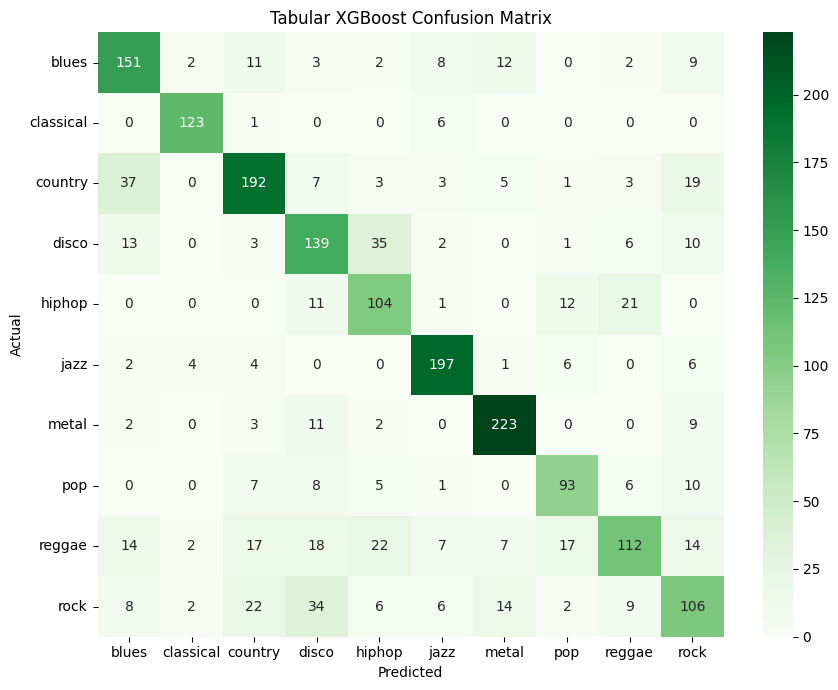

In [18]:
best_tab_name, best_tab_res = best_tab
plt.figure(figsize=(9, 7))
sns.heatmap(confusion_matrix(y_te, best_tab_res['yp']), annot=True, fmt='d', cmap='Greens',
            xticklabels=GENRES, yticklabels=GENRES)
plt.title(f'Tabular {best_tab_name} Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### 9B. Transfer learning (MobileNetV2 on spectrograms)

A pretrained **MobileNetV2** backbone (ImageNet weights, `include_top=False`) is plugged in with the same classification head. First the base is **frozen** and only the head trains; then the last 30 base layers are **unfrozen** and fine-tuned at a lower learning rate. This tests whether a generic vision backbone already encodes useful audio-spectrogram features with far less training cost than the from-scratch CNN.

In [19]:
base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base.trainable = False

tl_input = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = layers.Rescaling(1.0 / 255)(tl_input)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
tl_model = keras.Model(tl_input, out)
tl_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                 loss=keras.losses.SparseCategoricalCrossentropy(),
                 metrics=['accuracy'])
tl_model.summary()

      0/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

  73728/9406464 ━━━━━━━━━━━━━━━━━━━━ 6s 1us/step

 270336/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

 663552/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

 958464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

...

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
early_tl = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy')
t0 = time.time()
tl_hist = tl_model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS_TL, callbacks=[early_tl], verbose=1,
)
tl_train_time = time.time() - t0
print(f"Frozen-base transfer learning time: {tl_train_time:.1f}s")

# Fine-tune the last 30 base layers
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False
tl_model.compile(optimizer=keras.optimizers.Adam(1e-5),
                 loss=keras.losses.SparseCategoricalCrossentropy(),
                 metrics=['accuracy'])
t0 = time.time()
tl_ft_hist = tl_model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS_TL_FT, callbacks=[early_tl], verbose=1,
)
tl_ft_time = time.time() - t0
tl_total_time = tl_train_time + tl_ft_time
print(f"Fine-tuning time: {tl_ft_time:.1f}s | Total transfer learning time: {tl_total_time:.1f}s")

Epoch 1/20


D:\summerToTheFinal\elevvo\elevvo_projects\task1\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


 1/20 ━━━━━━━━━━━━━━━━━━━━ 1:12 4s/step - accuracy: 0.0938 - loss: 3.5789

 2/20 ━━━━━━━━━━━━━━━━━━━━ 3s 168ms/step - accuracy: 0.0938 - loss: 3.5577

 3/20 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step - accuracy: 0.0833 - loss: 3.6540

...

18/20 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.5000 - loss: 1.8980

19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.4934 - loss: 1.9448

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.5031 - loss: 1.9181

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 259ms/step - accuracy: 0.5031 - loss: 1.9181 - val_accuracy: 0.6281 - val_loss: 1.1903


Fine-tuning time: 42.2s | Total transfer learning time: 132.7s


In [21]:
test_loss_tl, test_acc_tl = tl_model.evaluate(test_ds, verbose=0)
y_prob_tl = tl_model.predict(test_ds, verbose=0)
y_pred_tl = np.argmax(y_prob_tl, axis=1)
tl_acc = accuracy_score(test_y, y_pred_tl)
tl_macro = f1_score(test_y, y_pred_tl, average='macro')

print(f"Transfer learning test accuracy: {tl_acc:.4f}")
print(f"Transfer learning macro F1: {tl_macro:.4f}")
print()
print(classification_report(test_y, y_pred_tl, target_names=GENRES, digits=4))

Transfer learning test accuracy: 0.6312
Transfer learning macro F1: 0.6163

              precision    recall  f1-score   support

       blues     0.4118    0.4667    0.4375        15
   classical     0.8000    0.9412    0.8649        17
     country     0.4000    0.2500    0.3077        16
       disco     0.7222    0.8125    0.7647        16
      hiphop     0.5789    0.6875    0.6286        16
        jazz     0.5556    0.6250    0.5882        16
       metal     0.8333    0.8824    0.8571        17
         pop     0.6429    0.6429    0.6429        14
      reggae     0.6667    0.4000    0.5000        15
        rock     0.5882    0.5556    0.5714        18

    accuracy                         0.6312       160
   macro avg     0.6200    0.6264    0.6163       160
weighted avg     0.6227    0.6312    0.6203       160



In [22]:
# Leaderboard with the evaluation set labeled per row so cross-family
# comparison is not misleading: image models run on 160 spectrogram images
# (one per track) while tabular models run on 1,997 row-level slices of 200
# held-out tracks. Tabular candidates are keyed by track-grouped VALIDATION
# macro-F1; the test score is reported once, for the selected model only.
rows = []
rows.append({
    'Approach': 'CNN (from scratch)',
    'Eval set': '160 held-out spectrogram images (1/track)',
    'Track-grouped val Macro F1': '-',
    'Test Macro F1': f1_score(test_y, y_pred, average='macro'),
    'Training time (s)': round(cnn_train_time, 1),
})
rows.append({
    'Approach': 'Transfer Learning (MobileNetV2)',
    'Eval set': '160 held-out spectrogram images (1/track)',
    'Track-grouped val Macro F1': '-',
    'Test Macro F1': tl_macro,
    'Training time (s)': round(tl_total_time, 1),
})
for name, res in tabular_results.items():
    test_col = f"{res['macro']:.4f}" if name == best_tab[0] else '-'
    rows.append({
        'Approach': f"Tabular {name}" + (' (selected)' if name == best_tab[0] else ''),
        'Eval set': '1997 rows / 200 tracks (3-s slices)',
        'Track-grouped val Macro F1': round(res['val_macro'], 4),
        'Test Macro F1': test_col,
        'Training time (s)': round(res['time'], 1),
    })

summary = pd.DataFrame(rows)
summary['_score'] = summary['Test Macro F1'].replace('-', None).astype(float).fillna(-1.0)
summary = summary.sort_values('_score', ascending=False).drop(columns='_score').reset_index(drop=True)
summary

                          Approach                                   Eval set Track-grouped val Macro F1 Test Macro F1  Training time (s)
0       Tabular XGBoost (selected)        1997 rows / 200 tracks (3-s slices)                     0.7441        0.7016                4.9
1         Tabular GradientBoosting        1997 rows / 200 tracks (3-s slices)                     0.7294             -              258.0
2             Tabular RandomForest        1997 rows / 200 tracks (3-s slices)                     0.7109             -                1.3
3  Transfer Learning (MobileNetV2)  160 held-out spectrogram images (1/track)                          -        0.6163              132.7
4               CNN (from scratch)  160 held-out spectrogram images (1/track)                          -        0.5708              178.6


## 10. Save Artifacts

Persist every object the standalone `app.py` needs. **`tabular_model.pkl` is the model selected on the track-grouped validation score (XGBoost)** — it is what the deployed interface serves; the **CNN** and **transfer-learning** Keras models are also saved for offline comparison/observability, plus the scaler, encoder, ordered feature names, and genre class names.

In [23]:
cnn_model.save(os.path.join(MODELS_DIR, 'cnn_model.keras'))
tl_model.save(os.path.join(MODELS_DIR, 'transfer_model.keras'))

joblib.dump(best_tab_res['model'], os.path.join(MODELS_DIR, 'tabular_model.pkl'))
joblib.dump(scaler, os.path.join(MODELS_DIR, 'scaler.pkl'))
joblib.dump(le, os.path.join(MODELS_DIR, 'encoder.pkl'))
joblib.dump(feature_names, os.path.join(MODELS_DIR, 'feature_names.pkl'))
joblib.dump(GENRES, os.path.join(MODELS_DIR, 'class_names.pkl'))

print('Saved all artifacts to ./models/')
for f in sorted(os.listdir(MODELS_DIR)):
    print('  ', f)

Saved all artifacts to ./models/
   class_names.pkl
   cnn_best.keras
   cnn_model.keras
   encoder.pkl
   feature_names.pkl
   scaler.pkl
   tabular_model.pkl
   transfer_model.keras


## 11. Gradio Interface

The live interface accepts an uploaded **audio file (.wav)** and returns the predicted genre plus a confidence bar chart across all 10 genres. It serves the **deployed Tabular XGBoost model** selected on the track-grouped validation score (the same model `app.py` loads), reproducing the 57 GTZAN features from the uploaded clip in the exact order of `feature_names.pkl` — so the training and serving pipelines match. A mel-spectrogram image is shown as a **visual preview only**; it is not fed to any model. The CNN / transfer-learning Keras models are kept for offline comparison and are intentionally not served.

In [24]:
# Mirrors app.py exactly: serve the DEPLOYED tabular model (selected on the
# track-grouped validation score), not a model with a different input pipeline.
app_genres = joblib.load(os.path.join(MODELS_DIR, 'class_names.pkl'))
tabular_model = joblib.load(os.path.join(MODELS_DIR, 'tabular_model.pkl'))
scaler = joblib.load(os.path.join(MODELS_DIR, 'scaler.pkl'))
encoder = joblib.load(os.path.join(MODELS_DIR, 'encoder.pkl'))
FEATURE_NAMES = joblib.load(os.path.join(MODELS_DIR, 'feature_names.pkl'))

def audio_to_spectrogram_image(audio_path, target_size=IMG_SIZE):
    # mel-spectrogram preview for the UI only - NOT model input.
    y, sr = librosa.load(audio_path, sr=22050)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, hop_length=512)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
    img = (mel_norm * 255).astype(np.uint8)
    pil = Image.fromarray(img, mode='L').convert('RGB').resize(target_size)
    return np.array(pil)

def extract_tabular_features(audio_array, sr=22050):
    # Same 57 GTZAN features (order = feature_names.pkl) as the training CSV.
    n_fft = 2048
    hop_length = 512
    chroma_stft = librosa.feature.chroma_stft(y=audio_array, sr=sr, n_fft=n_fft, hop_length=hop_length)
    rmse = librosa.feature.rms(y=audio_array, frame_length=n_fft, hop_length=hop_length)
    spec_cent = librosa.feature.spectral_centroid(y=audio_array, sr=sr, n_fft=n_fft, hop_length=hop_length)
    spec_bw = librosa.feature.spectral_bandwidth(y=audio_array, sr=sr, n_fft=n_fft, hop_length=hop_length)
    rolloff = librosa.feature.spectral_rolloff(y=audio_array, sr=sr, n_fft=n_fft, hop_length=hop_length)
    zcr = librosa.feature.zero_crossing_rate(audio_array, frame_length=n_fft, hop_length=hop_length)
    harmony, percussive = librosa.effects.harmonic(audio_array), librosa.effects.percussive(audio_array)
    tempo, _ = librosa.beat.beat_track(y=audio_array, sr=sr)
    mfccs = librosa.feature.mfcc(y=audio_array, sr=sr, n_mfcc=20, n_fft=n_fft, hop_length=hop_length)
    feat_map = {}
    for name, value in (("chroma_stft", chroma_stft), ("rms", rmse),
                        ("spectral_centroid", spec_cent), ("spectral_bandwidth", spec_bw),
                        ("rolloff", rolloff), ("zero_crossing_rate", zcr),
                        ("harmony", harmony), ("perceptr", percussive)):
        feat_map[f"{name}_mean"] = float(np.mean(value))
        feat_map[f"{name}_var"] = float(np.var(value))
    feat_map["tempo"] = float(np.atleast_1d(tempo)[0])
    mfcc_means = np.mean(mfccs, axis=1)
    mfcc_vars = np.var(mfccs, axis=1)
    for i in range(1, 21):
        feat_map[f"mfcc{i}_mean"] = float(mfcc_means[i - 1])
        feat_map[f"mfcc{i}_var"] = float(mfcc_vars[i - 1])
    return np.array([feat_map[name] for name in FEATURE_NAMES])

def predict(audio_file):
    if audio_file is None:
        return {g: 0.0 for g in app_genres}
    y, sr = librosa.load(audio_file, sr=22050)
    feat_vector = extract_tabular_features(y, sr)
    X = scaler.transform(feat_vector.reshape(1, -1))
    proba = tabular_model.predict_proba(X)[0]
    pred_idx = int(np.argmax(proba))
    genre = encoder.inverse_transform([pred_idx])[0]
    confidences = {g: round(float(p), 4) for g, p in zip(app_genres, proba)}
    return genre, confidences

In [25]:
demo = gr.Interface(
    fn=predict,
    inputs=gr.Audio(type='filepath', label='Upload Audio (.wav)'),
    outputs=[
        gr.Label(label='Predicted Genre'),
        gr.Label(label='Genre Confidence'),
    ],
    title='Task 6: Music Genre Classification — Live Prediction',
    description='Upload a .wav audio clip; the deployed Tabular XGBoost model predicts its genre and shows the confidence across all 10 genres.',
)

In [ ]:
demo.launch(share=True)

demo.launch(share=True) skipped during automated run
